In [2]:
import requests
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import json
from pathlib import Path

In [3]:
files = list(Path("sne-2015-2019-master").glob("*.json")) # son 27.624

In [4]:
from pathlib import Path

files = list(Path("sne-2015-2019-master").glob("*.json")) # son 27.624

n = 0  # 0 = primera, 1 = segunda, etc.
min_points = 20

encontradas = []

for file in files:

    with open(file, encoding="utf-8") as f:
        data = json.load(f)

    nombre = next(iter(data))

    if len(data[nombre].get("photometry", [])) >= 20:

        print("Nombre:", nombre)
        print("Observaciones:", len(data[nombre]["photometry"]))
        break


Nombre: ASASSN-15ae
Observaciones: 79


In [5]:
nombre = next(iter(data))
phot = data[nombre]["photometry"]
sn = data[nombre]
print(sn.get("claimedtype", "sin_claimedtype"))
print(nombre)

rows = []
for obs in phot:

    if "time" in obs and "magnitude" in obs:

        rows.append({
            "time": float(obs["time"]),
            "mag": float(obs["magnitude"]),
            "band": obs.get("band", "sin_banda")
        })

df = pd.DataFrame(rows)

print(df.head())

[{'value': 'Ia', 'source': '2,3,4,6,7,9,11,13,14'}]
ASASSN-15ae
          time      mag       band
0  57030.50000  16.1000  sin_banda
1  57032.88072  16.8100          G
2  57032.95472  16.8000          G
3  57051.76200  16.8026          g
4  57051.76300  16.8061          r


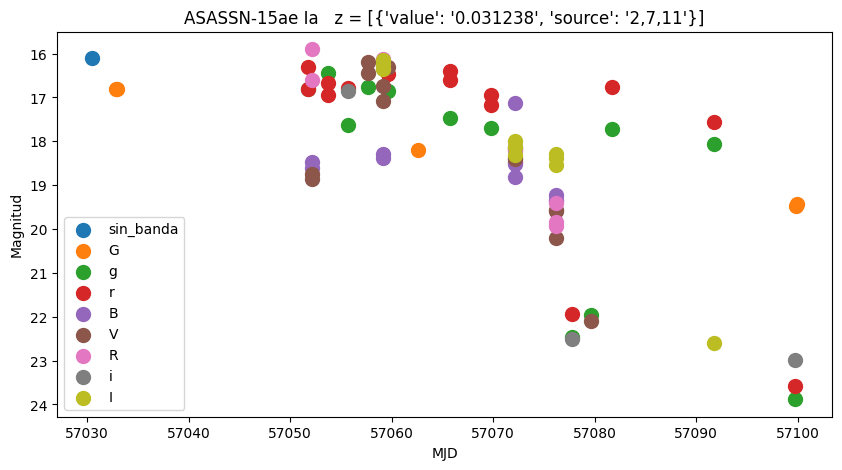

In [9]:
plt.figure(figsize=(10,5))

for band in df["band"].unique():

    sub = df[df["band"] == band]

    plt.scatter(sub["time"], sub["mag"], label=band, s=100
    )

plt.xlabel("MJD")
plt.ylabel("Magnitud")
plt.title("ASASSN-15ae Ia   z = " + str(sn.get("redshift", "sin_redshift")))
plt.gca().invert_yaxis()
plt.legend()

plt.show()